In [8]:
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import statsmodels.api as sm
import scipy.stats as stats

# <center>  6. Проверка на нормальность

Любое нормальное распределение обладает следующими свойствами:

* Один пик в центре и симметричные боковые стороны (одномодальное распределение).
* Среднее и медиана равны и расположены в центре распределения.
* Отклонение значений от среднего подчиняется правилу трёх сигм:
    * 68 % значений находятся в пределах одного стандартного отклонения от среднего;
    * 95 % значений — в пределах двух стандартных отклонений;
    * 99.7% значений — в пределах трёх стандартных отклонений.

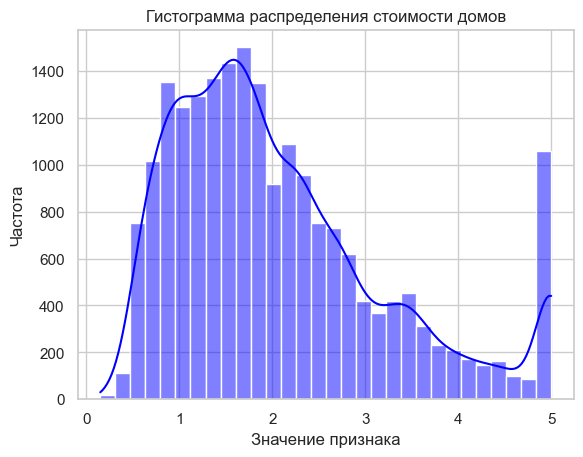

In [5]:
# загружаем данные
dataset = datasets.fetch_california_housing()
data = dataset.target

# задаём параметры гистограммы
sns.set(style="whitegrid")  # Setting the style of the plot
ax = sns.histplot(data, bins=30, kde=True, color='blue')
ax.set(xlabel='Значение признака', ylabel='Частота')
plt.title('Гистограмма распределения стоимости домов')

# отображаем гистограмму
plt.show()

Форма гистограммы несимметрична, с двумя пиками. Отсюда делаем промежуточный вывод: распределение стоимости домов не является нормальным.

### КВАНТИЛЬ-КВАНТИЛЬ ГРАФИК

>Квантиль-квантиль график (Q-Q Plot) визуализирует, насколько распределение выборки близко к нормальному. График показывает взаимное расположение квантилей наблюдаемого и теоретического нормального распределения. Хороший гайд по Q-Q Plots.

Если все точки лежат вдоль диагонали, то мы считаем, что данные в выборке распределены нормально

В Python квантиль-квантиль график можно построить с помощью функции qqplot() пакета statsmodels. Построение квантиль-квантиль графика мы также рассмотрим на примере стоимости домов из датасета California Housing:

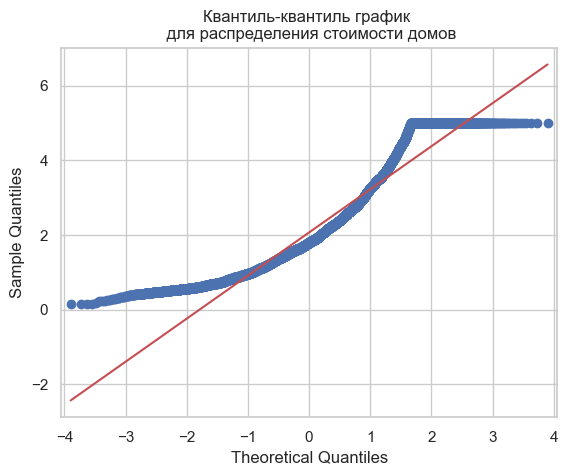

In [7]:
# загружаем данные
dataset = datasets.fetch_california_housing()
data = dataset.target

# задаём параметры квантиль-квантиль графика
sm.qqplot(data, line='s')
plt.title('Квантиль-квантиль график \n для распределения стоимости домов')

# отображаем квантиль-квантиль график
plt.show()

Точки не располагаются на диагонали — распределение стоимости домов не является нормальным (как мы видели и по гистограмме).

Графические методы могут быть неудобны в граничных случаях, когда сложно визуально определить, нормально ли распределение. Например, распределение может быть симметричным и похожим на колокол, но не соответствовать другим признакам нормального распределения. Также гистограмма и Q-Q Plot неинформативны на маленьких выборках.

В таких случаях на помощь приходят специальные статистические тесты.

## <center>СТАТИСТИЧЕСКИЕ МЕТОДЫ ПРОВЕРКИ НА НОРМАЛЬНОСТЬ

>>Существует несколько статистических методов, которые позволяют получить количественную оценку для проверки на нормальность. Мы рассмотрим наиболее часто встречающийся метод — тест Шапиро — Уилка.

>Тест Шапиро — Уилка оценивает выборку данных и определяет, насколько вероятно, что данные были получены из нормального распределения.

Тест хорошо работает на выборках до 5000 объектов.

Гипотезы в основе теста:

* Нулевая: данные распределены нормально.
* Альтернативная: данные не распределены нормально.

[Детали расчёта p-value в тесте Шапиро — Уилка.](http://www.machinelearning.ru/wiki/index.php?title=Критерий_Шапиро-Уилка)

Если p-value теста больше уровня значимости , то мы считаем, что данные распределены нормально.

### ПРИМЕР ИСПОЛЬЗОВАНИЯ ТЕСТА НА PYTHON

В Python тест Шапиро — Уилка реализован в функции shapiro() пакета scipy. Эта функция принимает на вход выборочные данные, а выдаёт p-значение и дополнительный параметр — статистику теста.

>Примечание. Статистика теста не будет нас интересовать, так как её интерпретация, в отличие от p-value, зависит от конкретного типа теста. Поэтому для проведения статистических тестов здесь и далее мы будем ориентироваться только на значение p-value.

Рассмотрим пример использования этой функции.

Допустим, нам необходимо проверить, нормально ли распределение количества заказов в день в некотором интернет-магазине. Чтобы правильно выбрать тест, количество заказов нужно проверить на нормальность:

In [9]:
import scipy.stats as stats

# задаём уровень значимости
alpha = 0.05 

# загружаем данные
data = [31, 38, 30, 58, 40, 36, 38, 44, 43, 39, 36, 41, 37, 20, 38, 35, 38, 11, 42, 34]

# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data)

print('p-value = %.3f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

# p-value = 0.015
# Распределение не нормальное

p-value = 0.015
Распределение не нормальное


Мы рассмотрели графические и статистические методы проверки на нормальность. Их можно использовать как вместе, так и по отдельности.

Тест Шапиро — Уилка — не единственный метод проверки на нормальность. Существуют и другие, например, [тест Д’Агостино](https://lms.skillfactory.ru/asset-v1:SkillFactory+DSPR-2.0+14JULY2021+type@asset+block/guid_normal_tets.pdf) или [тест Колмогорова — Смирнова](http://www.machinelearning.ru/wiki/index.php?title=Критерий_Колмогорова-Смирнова). У всех этих методов разные принципы работы, но очень похожие результаты, поэтому в большинстве случаев можно использовать любой из них. [Ещё больше способов проверки на нормальность.](https://questu.ru/articles/197465/)

Ранее мы говорили, что для нормально распределённых данных можно использовать параметрические тесты. Теперь мы умеем проверять, является ли распределение нормальным, а значит, настало время обсудить параметрические тесты. Но прежде давайте закрепим полученные знания небольшим тестом.

In [13]:
# задаём уровень значимости
alpha = 0.05 

# загружаем данные
data = [12,  8,  9, 10, 11, 12,  7, 12,  2, 10,  3,  9, 18, 4, 11, 13, 13, 17, 14,  3, 10,  2,  2,  7, 14,  8, 20,  5,  7, 10]

# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data)

print('p-value = %.3f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

p-value = 0.414
Распределение нормальное
